<div style="background:#123B63;color:white;padding:14px 18px;border-radius:6px">
<b>CSE 816 &mdash; Machine Learning Lab</b> &nbsp;&middot;&nbsp; Department of CSE, University of Chittagong<br>
<span style="font-size:90%">Module 1 &middot; Week 3 &middot; Part 2 of 4 &nbsp;&middot;&nbsp; 60 minutes</span>
</div>

# Decision Boundaries and the Logistic Loss

Part 1 built the model. This part builds the **cost**.

The first half is geometry: where a logistic model draws its boundary, and how polynomial
features bend that boundary into shapes a straight line cannot make. The second half is the
question the geometry cannot answer &mdash; *which* parameters? Squared error, which served
every model so far, turns out to be unusable here, and the replacement is not invented but
derived.

**Companion theory lecture:** CSE 815, Week 3, Part 1 (Decision Boundaries and the Cost
Function for Logistic Regression).

## What you will be able to do

1. Draw the decision boundary of a two-feature logistic model, and read it off the parameters
   without fitting anything.
2. Build polynomial features and produce a curved boundary from a model that is still linear
   in its parameters.
3. Demonstrate, with a two-point certificate anyone can check, that squared error on a sigmoid
   model is **not** convex.
4. Show that the squared-error gradient vanishes exactly where the model is most wrong.
5. Implement the logistic loss in both its two-case and one-line forms, and prove they agree.
6. Implement the logistic cost so that it survives `f = 0.0` and `f = 1.0`.

---

## 1. Setup

Everything from Part 1, restated so this notebook stands alone.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

np.set_printoptions(precision=4, suppress=True)

BLUE, TEAL, AMBER, ROSE, GRAY = "#123B63", "#1B7F79", "#C97B17", "#9B2C4B", "#4A5560"


def sigmoid(z):
    """Numerically stable sigmoid; carried over from Part 1."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out[()] if out.ndim == 0 else out


def load_loans(seed=816, m=120):
    """Chattogram microfinance borrowers. Returns X (income, debt%) and y (1 = repaid)."""
    rng = np.random.default_rng(seed)
    income = np.round(rng.uniform(12, 90, m), 1)
    debt = np.round(rng.uniform(2, 58, m), 1)
    z = 0.105 * (income - 42.0) - 0.125 * (debt - 28.0)
    y = (rng.random(m) < 1.0 / (1.0 + np.exp(-z))).astype(float)
    return np.column_stack([income, debt]), y


def load_screening():
    """Eight patients: tumour diameter (cm), 1 = malignant. Small enough to work
    through by hand, and deliberately not separable -- the 2 cm tumour was malignant
    and the 5 cm one was not."""
    return np.arange(1.0, 9.0).reshape(-1, 1), np.array([0., 1, 0, 0, 0, 1, 1, 1])


def load_rings(seed=3, m=160):
    """A deliberately artificial set: the positive class is a disc, not a half-plane.
    It exists to make the *shape* of a boundary visible, nothing more."""
    rng = np.random.default_rng(seed)
    radius = np.sqrt(rng.uniform(0, 4.0, m))
    angle = rng.uniform(0, 2 * np.pi, m)
    X = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
    y = (radius < 1.15).astype(float)
    flip = rng.random(m) < 0.06                     # 6% label noise
    y[flip] = 1 - y[flip]
    return np.round(X, 3), y


X_loan, y_loan = load_loans()
X_scr, y_scr = load_screening()
print("loans    :", X_loan.shape, " repaid:", int(y_loan.sum()))
print("screening:", X_scr.shape, " malignant:", int(y_scr.sum()))

loans    : (120, 2)  repaid: 63
screening: (8, 1)  malignant: 4


---

## 2. The decision boundary in two dimensions

At threshold $\tfrac12$ the sigmoid drops out and the rule is $\mathbf{w}\cdot\mathbf{x}+b \ge 0$.
With two features that is a **line**:

$$w_1x_1 + w_2x_2 + b = 0
  \qquad\Longleftrightarrow\qquad
  x_2 = -\frac{b}{w_2} - \frac{w_1}{w_2}x_1$$

It is a property of the parameters alone. You can draw it before seeing any data.

Part 3 fits these values; for now take them and read them.

In [2]:
def boundary_line(w, b, x1):
    """x2 along the decision boundary, for given x1. Requires w[1] != 0."""
    return (-b - w[0] * x1) / w[1]


# The converged fit from Part 3.
w_loan = np.array([0.101998, -0.154147])
b_loan = -0.247718

x1 = np.array([12.0, 90.0])
print(f"boundary:  debt = {-b_loan / w_loan[1]:.6f} + {-w_loan[0] / w_loan[1]:.6f} * income")
for inc in [15.0, 50.0, 88.0]:
    print(f"   income {inc:5.1f} k BDT  ->  boundary at debt = {boundary_line(w_loan, b_loan, inc):6.2f} %")

p_loan = sigmoid(X_loan @ w_loan + b_loan)
pred = (p_loan >= 0.5).astype(float)
print(f"\naccuracy at threshold 0.5: {(pred == y_loan).mean():.4f}")

# Thresholding the probability and thresholding w.x + b must agree.
assert np.array_equal(p_loan >= 0.5, (X_loan @ w_loan + b_loan) >= 0)

boundary:  debt = -1.607024 + 0.661693 * income
   income  15.0 k BDT  ->  boundary at debt =   8.32 %
   income  50.0 k BDT  ->  boundary at debt =  31.48 %
   income  88.0 k BDT  ->  boundary at debt =  56.62 %

accuracy at threshold 0.5: 0.8417


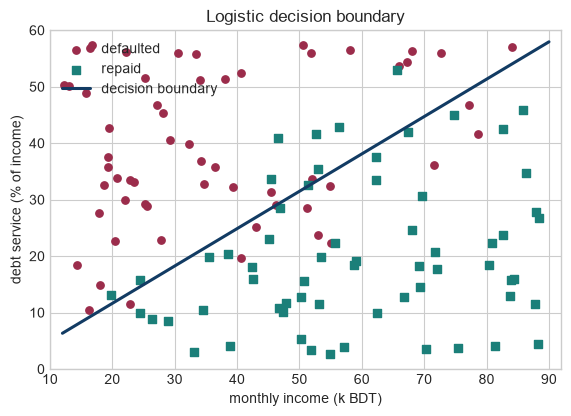

19 of 120 borrowers are on the wrong side of the line.
Every one of them is a point the model got wrong; no straight line does better here.


In [3]:
fig, ax = plt.subplots(figsize=(6.6, 4.4))
for label, colour, marker, name in [(0.0, ROSE, "o", "defaulted"), (1.0, TEAL, "s", "repaid")]:
    sel = y_loan == label
    ax.scatter(X_loan[sel, 0], X_loan[sel, 1], c=colour, marker=marker, s=28, label=name)
ax.plot(x1, boundary_line(w_loan, b_loan, x1), c=BLUE, lw=2.2, label="decision boundary")
ax.set_xlim(10, 92)
ax.set_ylim(0, 60)
ax.set_xlabel("monthly income (k BDT)")
ax.set_ylabel("debt service (% of income)")
ax.set_title("Logistic decision boundary")
ax.legend(loc="upper left")
plt.show()

wrong = np.where(pred != y_loan)[0]
print(f"{len(wrong)} of {len(y_loan)} borrowers are on the wrong side of the line.")
print("Every one of them is a point the model got wrong; no straight line does better here.")

---

## 3. Boundaries that are not straight

Nothing forces the *features* to be the raw measurements. Week 2 built `area = frontage *
depth` and fitted polynomials; the same move works here, and it bends the boundary.

Give the model $(x_1, x_2, x_1^2, x_2^2, x_1x_2)$ and the boundary
$\mathbf{w}\cdot\mathbf{x}+b=0$ becomes a conic section &mdash; an ellipse, a hyperbola, a pair
of lines. The model is still linear in $\mathbf{w}$ and $b$, so every derivation still holds.

Start with parameters chosen by hand, so the shape is unmistakable.

In [4]:
def quad_features(X):
    """[x1, x2, x1^2, x2^2, x1*x2] -- the full quadratic basis for two features."""
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([x1, x2, x1 ** 2, x2 ** 2, x1 * x2])


# Chosen, not fitted: z = -(x1^2 + x2^2 - 1), so the boundary is the unit circle
# and the model predicts 1 INSIDE it.
w_circle = np.array([0.0, 0.0, -1.0, -1.0, 0.0])
b_circle = 1.0

probe = np.array([[0.0, 0.0], [0.5, 0.5], [1.0, 0.0], [2.0, 0.0]])
p_probe = sigmoid(quad_features(probe) @ w_circle + b_circle)
for pt, pp in zip(probe, p_probe):
    inside = pt[0] ** 2 + pt[1] ** 2 < 1
    print(f"  x = ({pt[0]:4.1f}, {pt[1]:4.1f})   r^2 = {pt[0]**2 + pt[1]**2:5.2f}   "
          f"P = {pp:.4f}   {'inside' if inside else 'outside'}")

# On the boundary itself the model must say exactly 1/2.
assert np.isclose(sigmoid(quad_features(np.array([[1.0, 0.0]])) @ w_circle + b_circle)[0], 0.5)
print("\nOn the unit circle the model reports exactly 0.5, as it must.")

  x = ( 0.0,  0.0)   r^2 =  0.00   P = 0.7311   inside
  x = ( 0.5,  0.5)   r^2 =  0.50   P = 0.6225   inside
  x = ( 1.0,  0.0)   r^2 =  1.00   P = 0.5000   outside
  x = ( 2.0,  0.0)   r^2 =  4.00   P = 0.0474   outside

On the unit circle the model reports exactly 0.5, as it must.


### The same thing, fitted

`load_rings` generates a set whose positive class is a **disc** of radius 1.15, with 6% of the
labels flipped. A straight line cannot do much with it; a quadratic can.

In [5]:
X_ring, y_ring = load_rings()
print(f"rings: {len(y_ring)} points, {int(y_ring.sum())} positive")


def fit_newton(X, y, iters=200):
    """Newton's method on the logistic cost. You will write gradient descent in Part 3;
    this is here only so the boundaries below are the genuinely optimal ones."""
    n = X.shape[1]
    w, b = np.zeros(n), 0.0
    A = np.column_stack([X, np.ones(len(y))])
    for _ in range(iters):
        f = sigmoid(X @ w + b)
        g = A.T @ (f - y) / len(y)
        H = A.T @ (A * (f * (1 - f))[:, None]) / len(y)
        step = np.linalg.solve(H + 1e-10 * np.eye(n + 1), g)
        w, b = w - step[:-1], b - step[-1]
    return w, b


w_lin, b_lin = fit_newton(X_ring, y_ring)
acc_lin = ((sigmoid(X_ring @ w_lin + b_lin) >= 0.5) == y_ring).mean()

Xq = quad_features(X_ring)
w_quad, b_quad = fit_newton(Xq, y_ring)
acc_quad = ((sigmoid(Xq @ w_quad + b_quad) >= 0.5) == y_ring).mean()

print(f"\nlinear features    : accuracy {acc_lin:.4f}")
print(f"quadratic features : accuracy {acc_quad:.4f}")
print(f"\nfitted w = {np.round(w_quad, 4)},  b = {b_quad:.4f}")
print("The x1^2 and x2^2 coefficients are both around -2, and the cross term x1*x2 is")
print("small: the model has discovered a roughly circular boundary without being told.")
print(f"implied radius = {np.sqrt(b_quad / ((-w_quad[2] - w_quad[3]) / 2)):.4f}   (true radius 1.15)")

assert acc_quad > acc_lin + 0.2, "the quadratic boundary should be far better here"

rings: 160 points, 54 positive

linear features    : accuracy 0.6625
quadratic features : accuracy 0.9125

fitted w = [ 0.0434 -0.0622 -2.2614 -1.7652 -0.1904],  b = 2.7497
The x1^2 and x2^2 coefficients are both around -2, and the cross term x1*x2 is
small: the model has discovered a roughly circular boundary without being told.
implied radius = 1.1687   (true radius 1.15)


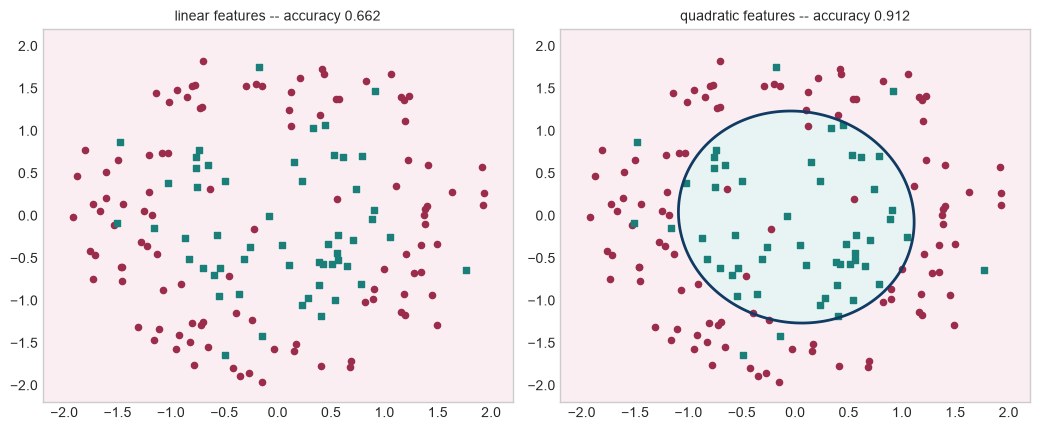

In [6]:
def plot_boundary(ax, X, y, predict_p, title, lim=2.2):
    """Draw the 0.5 contour of any probability function over a grid."""
    g = np.linspace(-lim, lim, 260)
    G1, G2 = np.meshgrid(g, g)
    P = predict_p(np.column_stack([G1.ravel(), G2.ravel()])).reshape(G1.shape)
    ax.contourf(G1, G2, P, levels=[0, 0.5, 1], colors=["#FBEEF2", "#E8F4F3"])
    ax.contour(G1, G2, P, levels=[0.5], colors=[BLUE], linewidths=2.0)
    for label, colour, marker in [(0.0, ROSE, "o"), (1.0, TEAL, "s")]:
        sel = y == label
        ax.scatter(X[sel, 0], X[sel, 1], c=colour, marker=marker, s=20)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)


fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
plot_boundary(axes[0], X_ring, y_ring,
              lambda G: sigmoid(G @ w_lin + b_lin),
              f"linear features -- accuracy {acc_lin:.3f}")
plot_boundary(axes[1], X_ring, y_ring,
              lambda G: sigmoid(quad_features(G) @ w_quad + b_quad),
              f"quadratic features -- accuracy {acc_quad:.3f}")
plt.tight_layout()
plt.show()

> The left panel is not a bad *fit*; it is the best straight line there is. The hypothesis
> space was wrong. Part 4 shows the other side of this: keep adding powers and the boundary
> will eventually wrap itself around individual noisy points.

---

## 4. Why squared error will not do

The model is now correct: its output is confined to $(0,1)$. So keep the cost from Week 1?

$$J_{\text{sq}}(\mathbf{w},b) = \frac{1}{2m}\sum_{i=1}^{m}
   \bigl(g(\mathbf{w}\cdot\mathbf{x}^{(i)}+b) - y^{(i)}\bigr)^2$$

It is bounded, differentiable, and entirely reasonable-looking. It is also unusable, for two
separate reasons.

### 4.1 It is not convex &mdash; and here is the certificate

Week 1 leaned hard on convexity: it is why any minimum gradient descent finds is *the*
minimum. A convex function lies below every chord: for any two parameter vectors
$\theta_0,\theta_1$ and any $t\in[0,1]$,

$$J\bigl((1-t)\theta_0 + t\theta_1\bigr) \;\le\; (1-t)J(\theta_0) + tJ(\theta_1)$$

To disprove convexity you need **one** $t$ where that fails. No eigenvalues required.

In [7]:
def cost_squared(X, y, w, b):
    """Squared error applied to the sigmoid model."""
    f = sigmoid(X @ w + b)
    return float(np.sum((f - y) ** 2) / (2 * len(y)))


def chord_gap(cost_fn, X, y, th0, th1, n=101):
    """max over t of  J(mix) - [linear interpolation of J].  Positive => not convex."""
    ts = np.linspace(0, 1, n)
    gaps = []
    for t in ts:
        w = (1 - t) * th0[0] + t * th1[0]
        b = (1 - t) * th0[1] + t * th1[1]
        mixed = cost_fn(X, y, w, b)
        chord = (1 - t) * cost_fn(X, y, *th0) + t * cost_fn(X, y, *th1)
        gaps.append(mixed - chord)
    gaps = np.array(gaps)
    return ts, gaps


# Two parameter vectors on the screening set: a bad model, and the good one.
theta_bad = (np.array([-1.0]), 4.0)       # "bigger tumours are safer"
theta_good = (np.array([0.594084]), -2.673380)

ts, gaps_sq = chord_gap(cost_squared, X_scr, y_scr, theta_bad, theta_good)
print(f"squared error:  largest chord violation = {gaps_sq.max():+.6f} at t = {ts[gaps_sq.argmax()]:.2f}")
print("A positive number here is a proof, not a hint: the squared-error cost is NOT convex.")

assert gaps_sq.max() > 0

squared error:  largest chord violation = +0.005899 at t = 0.17
A positive number here is a proof, not a hint: the squared-error cost is NOT convex.


Now the same test on the cost this part is about to derive.

logistic loss:  largest chord violation = +0.000000e+00
Never positive: the chord test finds no counterexample anywhere along this segment.


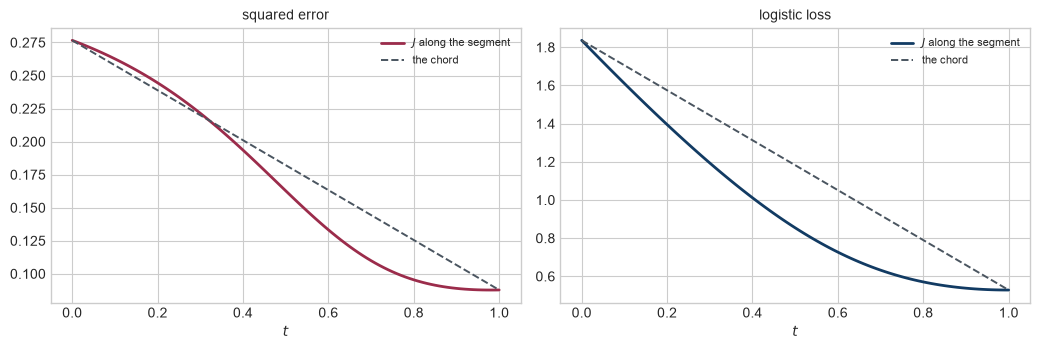

Left: the curve pokes above its own chord. Right: it never does.


In [8]:
def cost_logistic(X, y, w, b):
    """The logistic cost. Section 6 derives it; used here only for the comparison."""
    f = np.clip(sigmoid(X @ w + b), 1e-12, 1 - 1e-12)
    return float(-np.mean(y * np.log(f) + (1 - y) * np.log(1 - f)))


ts, gaps_log = chord_gap(cost_logistic, X_scr, y_scr, theta_bad, theta_good)
print(f"logistic loss:  largest chord violation = {gaps_log.max():+.6e}")
print("Never positive: the chord test finds no counterexample anywhere along this segment.")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for ax, cost_fn, name, colour in [(axes[0], cost_squared, "squared error", ROSE),
                                  (axes[1], cost_logistic, "logistic loss", BLUE)]:
    vals = [cost_fn(X_scr, y_scr, (1 - t) * theta_bad[0] + t * theta_good[0],
                    (1 - t) * theta_bad[1] + t * theta_good[1]) for t in ts]
    ax.plot(ts, vals, c=colour, lw=2.0, label="$J$ along the segment")
    ax.plot([0, 1], [vals[0], vals[-1]], c=GRAY, ls="--", lw=1.4, label="the chord")
    ax.set_xlabel("$t$")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

assert gaps_log.max() <= 1e-12
print("Left: the curve pokes above its own chord. Right: it never does.")

### 4.2 Its gradient vanishes exactly where the model is most wrong

Differentiating the per-example squared error with respect to $z$ gives

$$\frac{\partial}{\partial z}\tfrac12\bigl(g(z)-y\bigr)^2 = (f - y)\,f(1-f), \qquad f = g(z)$$

That trailing $f(1-f)$ is the sigmoid's derivative from Part 1, and it collapses to nothing in
both tails. A model that is confidently, catastrophically wrong sits in a tail.

In [9]:
print(f"{'f (with y=1)':>13} {'squared loss':>13} {'log loss':>10} "
      f"{'d(sq)/dz':>12} {'d(log)/dz':>11} {'ratio':>8}")
print("-" * 72)
for f in [0.9, 0.5, 0.1, 0.01, 0.001]:
    d_sq = (f - 1) * f * (1 - f)
    d_log = f - 1
    print(f"{f:13} {0.5 * (f - 1) ** 2:13.6f} {-np.log(f):10.6f} "
          f"{d_sq:12.8f} {d_log:11.6f} {d_log / d_sq:8.1f}")

print("\nRead down the squared-error column. Predicting 0.001 when the truth is 1 -- as")
print("wrong as a probability can be -- is charged 0.499, barely more than the 0.405")
print("charged for a mild error of 0.1, and its gradient is 0.000998. The algorithm is")
print("told almost nothing. The log loss charges 6.91 and returns a gradient 1001x larger.")

 f (with y=1)  squared loss   log loss     d(sq)/dz   d(log)/dz    ratio
------------------------------------------------------------------------
          0.9      0.005000   0.105361  -0.00900000   -0.100000     11.1
          0.5      0.125000   0.693147  -0.12500000   -0.500000      4.0
          0.1      0.405000   2.302585  -0.08100000   -0.900000     11.1
         0.01      0.490050   4.605170  -0.00980100   -0.990000    101.0
        0.001      0.499001   6.907755  -0.00099800   -0.999000   1001.0

Read down the squared-error column. Predicting 0.001 when the truth is 1 -- as
wrong as a probability can be -- is charged 0.499, barely more than the 0.405
charged for a mild error of 0.1, and its gradient is 0.000998. The algorithm is
told almost nothing. The log loss charges 6.91 and returns a gradient 1001x larger.


---

## 5. The logistic loss

Rather than patch squared error, derive the right cost. The model already claims
$\mathbb{P}(y=1\mid\mathbf{x}) = f$. **Maximum likelihood** turns that claim into a cost
mechanically: choose the parameters under which the labels we actually saw were most probable.

For one example, the two cases collapse into one expression because $y$ is 0 or 1:

$$\mathbb{P}(y\mid\mathbf{x}) = f^{\,y}(1-f)^{\,1-y}$$

Take the product over the training set, take logarithms (products of $m$ numbers below 1
underflow), negate (optimizers minimise) and divide by $m$:

$$L(f,y) = -y\ln f - (1-y)\ln(1-f), \qquad
  J(\mathbf{w},b) = \frac1m\sum_{i=1}^m L\bigl(f^{(i)}, y^{(i)}\bigr)$$

The two-case form is the one to reason with; the one-line form is the one to implement.

In [10]:
def loss_two_case(f, y):
    """The form to reason with."""
    return np.where(y == 1, -np.log(f), -np.log(1 - f))


def loss_one_line(f, y):
    """The form to implement."""
    return -y * np.log(f) - (1 - y) * np.log(1 - f)


f_probe = np.array([0.02, 0.2, 0.5, 0.8, 0.98])
for y_val in [0.0, 1.0]:
    a = loss_two_case(f_probe, y_val)
    b_ = loss_one_line(f_probe, np.full_like(f_probe, y_val))
    print(f"y = {y_val:.0f}:  {np.round(a, 4)}")
    assert np.allclose(a, b_)

print("\nThe two forms agree exactly; the exponents y and 1-y act as switches,")
print("each turning off the term that does not apply.")

y = 0:  [0.0202 0.2231 0.6931 1.6094 3.912 ]
y = 1:  [3.912  1.6094 0.6931 0.2231 0.0202]

The two forms agree exactly; the exponents y and 1-y act as switches,
each turning off the term that does not apply.


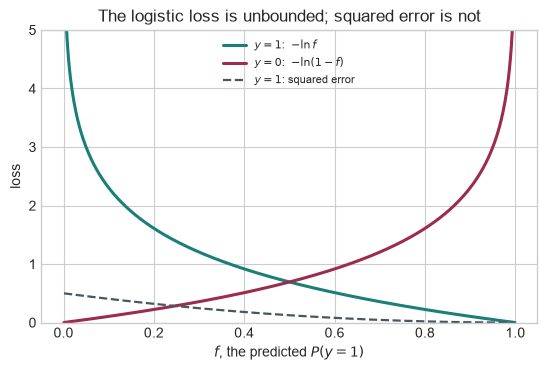

loss at f = 0.5 : 0.693147   (= ln 2)
loss at f = 0.001, y = 1 : 6.907755
squared error, same case : 0.499001   -- capped at 0.5, forever


In [11]:
f = np.linspace(1e-3, 1 - 1e-3, 500)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(f, -np.log(f), c=TEAL, lw=2.2, label="$y = 1$:  $-\\ln f$")
ax.plot(f, -np.log(1 - f), c=ROSE, lw=2.2, label="$y = 0$:  $-\\ln(1-f)$")
ax.plot(f, 0.5 * (f - 1) ** 2, c=GRAY, lw=1.6, ls="--", label="$y = 1$: squared error")
ax.set_xlabel("$f$, the predicted $P(y=1)$")
ax.set_ylabel("loss")
ax.set_ylim(0, 5)
ax.set_title("The logistic loss is unbounded; squared error is not")
ax.legend(fontsize=8)
plt.show()

print(f"loss at f = 0.5 : {-np.log(0.5):.6f}   (= ln 2)")
print(f"loss at f = 0.001, y = 1 : {-np.log(0.001):.6f}")
print(f"squared error, same case : {0.5 * (0.001 - 1) ** 2:.6f}   -- capped at 0.5, forever")

> **The unboundedness is the point.** Squared error caps the penalty for a confidently wrong
> prediction at $\tfrac12$; the logistic loss lets it grow without limit. That is exactly what
> keeps the gradient alive in the tails, and it is why a logistic model refuses to be
> confidently wrong about a training example if any parameters can avoid it.

---

## 6. The cost function, implemented properly

Part 1 measured where `float64` gives up: `sigmoid` returns exactly `1.0` above $z \approx 37$
and exactly `0.0` below $z \approx -745$. Then `np.log(1 - f)` is `np.log(0.0)`, which is
`-inf`, and the cost becomes `inf` or `nan`. Clip.

In [12]:
def compute_cost(X, y, w, b, eps=1e-12):
    """Average logistic loss. The clip is not cosmetic: without it a single saturated
    prediction makes the whole cost infinite."""
    f = sigmoid(X @ w + b)
    f = np.clip(f, eps, 1 - eps)
    return float(-np.mean(y * np.log(f) + (1 - y) * np.log(1 - f)))


def compute_cost_unclipped(X, y, w, b):
    f = sigmoid(X @ w + b)
    with np.errstate(divide="ignore", invalid="ignore"):
        return float(-np.mean(y * np.log(f) + (1 - y) * np.log(1 - f)))


# Parameters extreme enough to saturate the sigmoid on this data.
w_big, b_big = np.array([50.0]), -225.0
print("saturated predictions:", sigmoid(X_scr @ w_big + b_big))
print(f"  unclipped cost : {compute_cost_unclipped(X_scr, y_scr, w_big, b_big)}")
print(f"  clipped cost   : {compute_cost(X_scr, y_scr, w_big, b_big):.6f}")

assert not np.isfinite(compute_cost_unclipped(X_scr, y_scr, w_big, b_big))
assert np.isfinite(compute_cost(X_scr, y_scr, w_big, b_big))

saturated predictions: [0. 0. 0. 0. 1. 1. 1. 1.]
  unclipped cost : nan
  clipped cost   : 6.578877


### The reference value every logistic model has

At $\mathbf{w} = \mathbf{0}$, $b = 0$ every prediction is $g(0) = \tfrac12$, so

$$J = -\frac1m\sum_i \left[y^{(i)}\ln\tfrac12 + (1-y^{(i)})\ln\tfrac12\right] = \ln 2 \approx 0.693147$$

**whatever the data is.** A trained classifier whose cost is not clearly below `0.693` has
learned nothing a coin could not have told you. Check it on both data sets.

In [13]:
for name, X, y in [("screening", X_scr, y_scr), ("loans", X_loan, y_loan),
                   ("rings", X_ring, y_ring)]:
    J0 = compute_cost(X, y, np.zeros(X.shape[1]), 0.0)
    print(f"  {name:10s} J(0, 0) = {J0:.6f}")
    assert np.isclose(J0, np.log(2))

print(f"\nln 2 = {np.log(2):.6f}   -- the same for all three, as the algebra promises.")

print(f"\nAt the fitted parameters:")
print(f"  screening J = {compute_cost(X_scr, y_scr, np.array([0.594084]), -2.673380):.6f}")
print(f"  loans     J = {compute_cost(X_loan, y_loan, w_loan, b_loan):.6f}")

  screening  J(0, 0) = 0.693147
  loans      J(0, 0) = 0.693147
  rings      J(0, 0) = 0.693147

ln 2 = 0.693147   -- the same for all three, as the algebra promises.

At the fitted parameters:
  screening J = 0.528099
  loans     J = 0.308059


### Checkpoint 1

Write `cost_curve(X, y, w_fixed, b_values)` that evaluates `compute_cost` over a range of `b`
with `w` held fixed, and plot it for the screening set with `w = 0.594084` and `b` from `-6` to
`0`.

Read the minimum off your plot, then report:

1. the value of `b` (to two decimals) that minimises the cost on that grid;
2. the cost there.

*Expected:* the grid minimum is at about `b = -2.67`, with cost about `0.5281` &mdash; the
value quoted in section 6, because holding `w` at its optimum and minimising over `b` alone
lands on the joint optimum.

In [ ]:
# Your code here

### Checkpoint 2

Repeat the chord test of section 4 on the **loans** data, in two stages.

1. Test the segment from `theta0 = (np.zeros(2), 0.0)` to `theta1 = (w_loan, b_loan)`, for both
   costs. Report the largest violation for each.
2. That result is not the one you might expect, so hunt for a segment where squared error
   *does* fail. Start from a sign-flipped model, `w = np.array([-0.1, 0.15])`, `b = 3.0`, and
   run to the same `theta1`.

Then write two sentences on the asymmetry: a positive violation **proves** non-convexity,
while finding none along one segment proves nothing at all.

*Expected:* in stage 1 **both** costs give `0.0` &mdash; the squared-error cost happens to be
convex along that particular segment, which is exactly why stage 1 alone would have misled
you. In stage 2 squared error gives about `+0.009106` near `t = 0.175`, while the logistic
loss still gives `0.0`.

In [ ]:
# Your code here

---

## 7. Recap

- At threshold $\tfrac12$ the boundary is $\mathbf{w}\cdot\mathbf{x}+b = 0$: a point in 1-D, a
  line in 2-D, a hyperplane in general. It depends on the parameters, not on the data.
- Polynomial features bend the boundary into conics and beyond while the model stays linear in
  $\mathbf{w}$ and $b$, so every result from Weeks 1&ndash;2 survives.
- Squared error on a sigmoid model is **not convex**, and one chord violation proves it. Here
  the violation was $+0.0059$ on a segment through parameter space.
- Its gradient is $(f-y)f(1-f)$, which vanishes in both tails: a prediction of `0.001` against
  a target of `1` yields a gradient of `0.000998`.
- Maximum likelihood on the model's own assumption yields
  $L = -y\ln f - (1-y)\ln(1-f)$, with no further choices. It is unbounded above, which is
  precisely what keeps the gradient usable.
- Clip `f` before taking logarithms. `sigmoid` saturates to exactly `0.0` and `1.0` in
  `float64`, and one saturated prediction makes an unclipped cost `inf`.
- $J = \ln 2 = 0.693147$ at the origin for every data set. It is the number every trained
  classifier must beat.

### Exercises to hand in

1. Find a chord violation for the squared-error cost using two parameter vectors of your own,
   neither of which is the fitted optimum. Report both endpoints, the value of $t$, and the
   size of the violation.
2. The chord test is a *disproof* tool. Explain in a paragraph why running it on a thousand
   random segments and finding no violation would still not prove the logistic cost convex,
   and name the argument from the lecture that does prove it.
3. Plot the squared-error cost on the screening set as a surface over $(b, w)$ for
   $b\in[-8,8]$, $w\in[-3,3]$, and mark the region where it is flat to three decimal places.
   How much of the rectangle is plateau?
4. Repeat section 3 with cubic features $(x_1, x_2, x_1^2, x_2^2, x_1x_2, x_1^3, x_2^3, \ldots)$
   on the rings data. Report training accuracy and describe the shape of the boundary. Keep the
   plot: Part 4 asks you to explain it.
5. Show algebraically that $-y\ln f - (1-y)\ln(1-f)$ reduces to $-\ln f$ when $y=1$ and to
   $-\ln(1-f)$ when $y=0$, and explain why the same trick would fail if $y$ took the values
   $-1$ and $+1$.
6. Compute the logistic cost of a model that predicts the training-set base rate for every
   example, on the loans data. Compare with $\ln 2$ and with the fitted cost, and say what
   this third number is useful for.

### Next

**Part 3 &mdash; Gradient Descent for Logistic Regression:** the gradient, why it looks
identical to linear regression's without being the same algorithm, and how to turn
probabilities into decisions.

**Reading:** James et al., *ISL* 2e, &sect;4.3.2&ndash;4.3.4 (estimating the coefficients,
predictions, multiple logistic regression).